In [ ]:
import pandas as pd

## Initial Data Analysis

Loaded dataset and checked structure, null values, and distributions.

In [ ]:
df_emails = pd.read_csv('emails.csv')

In [ ]:
def analyze_dataset(df, name="Dataset"):
    print(f"\n===== {name} =====")
    
    print("\n--- Info ---")
    print(df.info())
    
    print("\n--- Summary ---")
    summary = pd.DataFrame({
        "Data Type": df.dtypes,
        "Null Count": df.isnull().sum(),
        "Unique Values": df.nunique()
    })
    print(summary)
    
    print("\n--- Categorical Columns ---")
    cat_cols = df.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        print(f"\n{col}")
        print(df[col].value_counts().head(10))
    
    print("\n--- Numerical Columns ---")
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    print(df[num_cols].describe())

In [ ]:
analyze_dataset(df_emails)

In [ ]:
pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')

## Data Filtering

Selected only records where Time_to_Renewal = 14_out for focused analysis.

In [ ]:
df = df_emails[df_emails['Time_to_Renewal'] == '14_out']
df

In [ ]:
cols = [
    'Co_Ref',

    # Customer intent 
    'crm_customer_payment_intention',
    'crm_contractor_suggested_leave',

    # Sentiment
    'crm_contractor_sentiment_score',

    # Customer pain 
    'crm_customer_complained',
    'crm_negative_customer_experience',
    'crm_dissatisfaction_with_support',

    'crm_competitors_mentioned',
    'crm_agent_chase_count',
    
    # Financial signals
    'crm_dissatisified_with_renewal_price',
    'crm_financial_hardship_mentioned',    

    # Process 
    'crm_delays_in_accreditation',

    # Risk flag
    'crm_membership_overdue'
]
df_final =df[cols]


## Feature Selection

Selected key columns related to intent, complaints, financial issues, and risk.

Dropped irrelevant columns to reduce noise.

In [ ]:
df_final['crm_agent_chase_count'] = pd.to_numeric(
    df_final['crm_agent_chase_count'], errors='coerce'
)

Converted crm_agent_chase_count to numeric.

In [ ]:
analyze_dataset(df_final)

In [ ]:
def clean_text(x):
    if pd.isna(x):
        return "Not Discussed"
    
    x = str(x).strip().lower()
    
    if "yes" in x:
        return "Yes"
    elif "no" in x:
        return "No"
    elif "not" in x:
        return "Not Discussed"
    else:
        return "Not Discussed"

In [ ]:
cat_cols = [
    'crm_customer_payment_intention',
    'crm_contractor_suggested_leave',
    'crm_customer_complained',
    'crm_negative_customer_experience',
    'crm_dissatisfaction_with_support',
    'crm_competitors_mentioned',
    'crm_dissatisified_with_renewal_price',
    'crm_financial_hardship_mentioned',
    'crm_delays_in_accreditation',
    'crm_membership_overdue'
]

for col in cat_cols:
    df_final[col] = df_final[col].apply(clean_text)

## Data Cleaning

Standardized categorical values into:
- Yes
- No
- Not Discussed

Removed inconsistent text values.

In [ ]:
df_final['crm_agent_chase_count'] = df_final['crm_agent_chase_count'].fillna(0)
df_final

In [ ]:
df_final = df_final.drop(columns=['crm_contractor_sentiment_score'])

In [ ]:
df_emails=df_final
analyze_dataset(df_emails)
# df_emails.to_csv('cleaned_emails.csv', index=False)

In [ ]:
df_bill= pd.read_csv('match 3.csv')

In [ ]:
df_merged = df_bill.merge(df_final, on='Co_Ref', how='inner')
df_merged

## Data Merge

Merged email data with billing data using Co_Ref to include churn outcome.

In [ ]:
analyze_dataset(df_merged)

In [ ]:
mapping = {
    'No': 0,
    'Not Discussed': 1,
    'Yes': 2
}

cols = [
    'crm_customer_payment_intention',
    'crm_contractor_suggested_leave',
    'crm_customer_complained',
    'crm_negative_customer_experience',
    'crm_dissatisfaction_with_support',
    'crm_competitors_mentioned',
    'crm_dissatisified_with_renewal_price',
    'crm_financial_hardship_mentioned',
    'crm_delays_in_accreditation',
    'crm_membership_overdue'
]

for col in cols:
    df_merged[col] = df_merged[col].map(mapping)

## Encoding

Converted categorical values:
- No → 0
- Not Discussed → 1
- Yes → 2

In [ ]:
df_merged['churn'] = df_merged['Prospect_Outcome'].map({
    'Churned': 1,
    'Won': 0
})

In [ ]:
df_corr = df_merged.drop(columns=[
    'Co_Ref',
    'Prospect_Outcome',
    'Prospect_Renewal_Date'
])

In [ ]:
# !pip install scipy

In [26]:
from scipy.stats import chi2_contingency
significant_features = []
insignificant_features = []

for col in cat_cols:
    contingency = pd.crosstab(df_merged[col].astype(str), df_merged['churn'])
    
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    print(f"{col} --> p-value: {p}")
    
    if p < 0.05:
        significant_features.append(col)
    else:
        insignificant_features.append(col)

print("\nSignificant Features:", significant_features)
print("\nNot Significant Features:", insignificant_features)

crm_customer_payment_intention --> p-value: 2.7882276691163103e-89
crm_contractor_suggested_leave --> p-value: 0.0
crm_customer_complained --> p-value: 9.703279144402778e-78
crm_negative_customer_experience --> p-value: 4.2076735390887724e-218
crm_dissatisfaction_with_support --> p-value: 9.221499865116004e-55
crm_competitors_mentioned --> p-value: 1.6916359450478824e-87
crm_dissatisified_with_renewal_price --> p-value: 1.058876544826322e-46
crm_financial_hardship_mentioned --> p-value: 0.0
crm_delays_in_accreditation --> p-value: 1.7328163465839298e-15
crm_membership_overdue --> p-value: 8.657938103783412e-32

Significant Features: ['crm_customer_payment_intention', 'crm_contractor_suggested_leave', 'crm_customer_complained', 'crm_negative_customer_experience', 'crm_dissatisfaction_with_support', 'crm_competitors_mentioned', 'crm_dissatisified_with_renewal_price', 'crm_financial_hardship_mentioned', 'crm_delays_in_accreditation', 'crm_membership_overdue']

Not Significant Features: []

## Correlation Analysis

Calculated correlation to identify features influencing churn.

In [28]:
corr_target = df_corr.corr()['churn'].sort_values(ascending=False)
print(corr_target)

churn                                   1.000000
crm_contractor_suggested_leave          0.208877
crm_negative_customer_experience        0.076711
crm_financial_hardship_mentioned        0.068572
crm_agent_chase_count                   0.025093
crm_customer_complained                 0.019659
crm_delays_in_accreditation             0.012233
crm_dissatisfaction_with_support        0.010097
crm_competitors_mentioned               0.000025
crm_dissatisified_with_renewal_price    0.000017
crm_membership_overdue                 -0.009204
crm_customer_payment_intention         -0.067591
Name: churn, dtype: float64


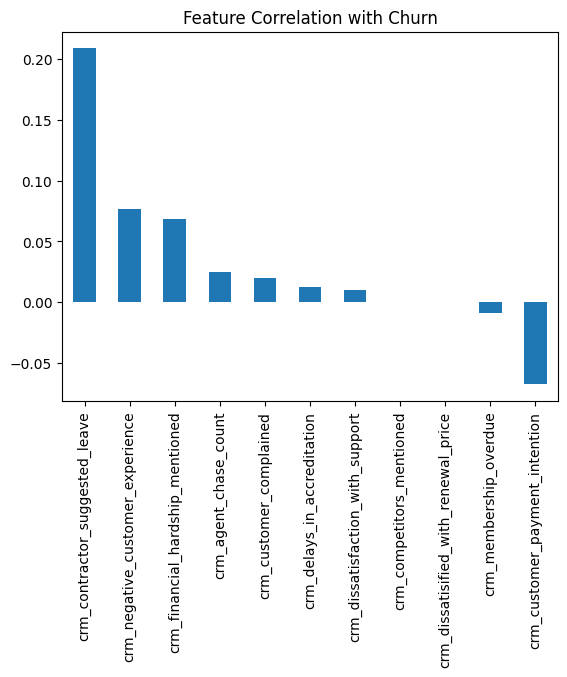

In [27]:
import matplotlib.pyplot as plt

corr_target.drop('churn').plot(kind='bar')
plt.title("Feature Correlation with Churn")
plt.show()

## Final Feature Selection Approach

Feature selection was done using:

1. Chi-Square Test → to check statistical significance  
2. Correlation Analysis → to measure strength of relationship  

Only features that are both meaningful and useful were retained.

In [29]:
drop_cols = [
    'crm_competitors_mentioned',
    'crm_dissatisified_with_renewal_price'
]

df_merged = df_merged.drop(columns=drop_cols)